In [1]:
import requests
import pandas as pd

print("Downloading Chicago crime data 2023...")

# Chicago open data API — no API key needed, free
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"

all_records = []
offset = 0
limit = 50000  # fetch 50k rows per request

while True:
    params = {
        "$limit": limit,
        "$offset": offset,
        "$where": "year = 2023",
        "$order": "date DESC"
    }
    response = requests.get(url, params=params)
    batch = response.json()
    
    if len(batch) == 0:
        break
    
    all_records.extend(batch)
    offset += limit
    print(f"  Fetched {len(all_records):,} records so far...")

df_raw = pd.DataFrame(all_records)
df_raw.to_csv("chicago_crimes_2023.csv", index=False)

print(f"\nDone! Total rows: {len(df_raw):,}")
print(f"Columns: {df_raw.columns.tolist()}")

  Fetched 50,000 records so far...
  Fetched 100,000 records so far...
  Fetched 150,000 records so far...
  Fetched 200,000 records so far...
  Fetched 250,000 records so far...
  Fetched 263,320 records so far...

Done! Total rows: 263,320
Columns: ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


In [2]:
import pandas as pd

df = pd.read_csv("chicago_crimes_2023.csv", low_memory=False)

print("Shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

# Standardize all column names to lowercase with underscores
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# Rename to consistent names used throughout notebook
df = df.rename(columns={
    "primary_type":           "Primary Type",
    "latitude":               "Latitude",
    "longitude":              "Longitude",
    "location_description":   "Location Description",
    "date":                   "Date",
    "district":               "District",
    "arrest":                 "Arrest",
    "year":                   "Year"
})

print("\nFixed columns:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (263320, 22)

Original columns:
['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']

Fixed columns:
['id', 'case_number', 'Date', 'block', 'iucr', 'Primary Type', 'description', 'Location Description', 'Arrest', 'domestic', 'beat', 'District', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'Year', 'updated_on', 'Latitude', 'Longitude', 'location']

First 3 rows:


,id,case_number,Date,block,iucr,Primary Type,description,Location Description,Arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,Year,updated_on,Latitude,Longitude,location
0,13327763,JH103488,2023-12-31T23:59:00.000,010XX N ORLEANS ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,27.0,8.0,14,1173727.0,1907173.0,2023,2024-12-21T15:40:46.000,41.900698,-87.637330,"{'latitude': '41.900698378', 'longitude': '-87..."
1,13325009,JH100002,2023-12-31T23:51:00.000,051XX S PRINCETON AVE,0550,ASSAULT,AGGRAVATED POLICE OFFICER - HANDGUN,STREET,True,False,...,20.0,37.0,04A,1175152.0,1871065.0,2023,2024-12-21T15:40:46.000,41.801584,-87.633177,"{'latitude': '41.801583507', 'longitude': '-87..."
2,13324997,JH100010,2023-12-31T23:51:00.000,009XX E 77TH ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,APARTMENT,False,True,...,8.0,69.0,04A,1183685.0,1854148.0,2023,2024-12-21T15:40:46.000,41.754967,-87.602411,"{'latitude': '41.754966726', 'longitude': '-87..."


In [3]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL COUNTS ===")
print(df.isnull().sum())

=== SHAPE ===
(263320, 22)

=== DATA TYPES ===
id                        int64
case_number              object
Date                     object
block                    object
iucr                     object
Primary Type             object
description              object
Location Description     object
Arrest                     bool
domestic                   bool
beat                      int64
District                  int64
ward                    float64
community_area          float64
fbi_code                 object
x_coordinate            float64
y_coordinate            float64
Year                      int64
updated_on               object
Latitude                float64
Longitude               float64
location                 object
dtype: object

=== NULL COUNTS ===
id                         0
case_number                0
Date                       0
block                      0
iucr                       0
Primary Type               0
description                0
Location De

In [4]:
print("Unique crime types:", df['Primary Type'].nunique())
print("\nTop 15 crime types:")
print(df['Primary Type'].value_counts().head(15))

Unique crime types: 31

Top 15 crime types:
Primary Type
THEFT                         57511
BATTERY                       44254
CRIMINAL DAMAGE               30094
MOTOR VEHICLE THEFT           29255
ASSAULT                       22632
DECEPTIVE PRACTICE            17530
OTHER OFFENSE                 15730
ROBBERY                       11050
WEAPONS VIOLATION              8608
BURGLARY                       7489
NARCOTICS                      5455
CRIMINAL TRESPASS              4722
OFFENSE INVOLVING CHILDREN     1756
CRIMINAL SEXUAL ASSAULT        1683
SEX OFFENSE                    1365
Name: count, dtype: int64


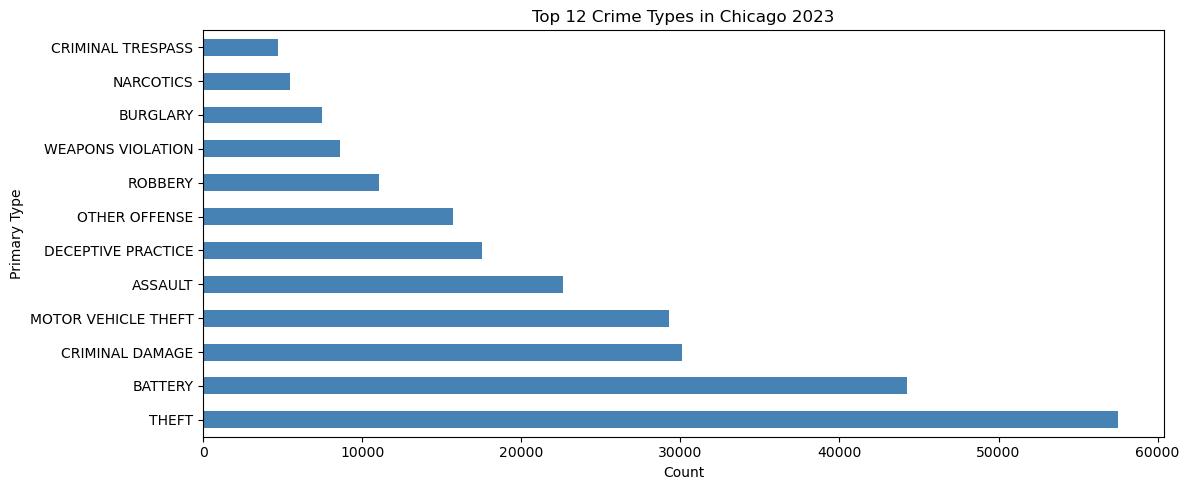

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)

df['Primary Type'].value_counts().head(12).plot(kind='barh', color='steelblue')
plt.title('Top 12 Crime Types in Chicago 2023')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [6]:
print("Before cleaning:", df.shape)

# Convert lat/lon to numeric first (they come as strings from API)
df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Drop rows with no location
df = df.dropna(subset=['Latitude', 'Longitude'])

# Keep only points inside Chicago bounding box
df = df[
    (df['Latitude']  >= 41.6) & (df['Latitude']  <= 42.1) &
    (df['Longitude'] >= -87.9) & (df['Longitude'] <= -87.5)
]

# Drop rows missing crime type
df = df.dropna(subset=['Primary Type'])

print("After cleaning:", df.shape)
df.head(3)

Before cleaning: (263320, 22)
After cleaning: (260444, 22)


,id,case_number,Date,block,iucr,Primary Type,description,Location Description,Arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,Year,updated_on,Latitude,Longitude,location
0,13327763,JH103488,2023-12-31T23:59:00.000,010XX N ORLEANS ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,27.0,8.0,14,1173727.0,1907173.0,2023,2024-12-21T15:40:46.000,41.900698,-87.637330,"{'latitude': '41.900698378', 'longitude': '-87..."
1,13325009,JH100002,2023-12-31T23:51:00.000,051XX S PRINCETON AVE,0550,ASSAULT,AGGRAVATED POLICE OFFICER - HANDGUN,STREET,True,False,...,20.0,37.0,04A,1175152.0,1871065.0,2023,2024-12-21T15:40:46.000,41.801584,-87.633177,"{'latitude': '41.801583507', 'longitude': '-87..."
2,13324997,JH100010,2023-12-31T23:51:00.000,009XX E 77TH ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,APARTMENT,False,True,...,8.0,69.0,04A,1183685.0,1854148.0,2023,2024-12-21T15:40:46.000,41.754967,-87.602411,"{'latitude': '41.754966726', 'longitude': '-87..."


In [7]:
# Parse Date column from string to datetime
df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True)

# Extract time features
df['hour']        = df['Date'].dt.hour
df['day_of_week'] = df['Date'].dt.dayofweek   # 0=Monday 6=Sunday
df['month']       = df['Date'].dt.month
df['year']        = df['Date'].dt.year
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)

print("Time features added successfully")
print(df[['Date','hour','day_of_week','month','is_weekend','is_night']].head(5))

C:\Users\vinjam rajesh\AppData\Local\Temp\ipykernel_14196\64975285.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True)


Time features added successfully
                 Date  hour  day_of_week  month  is_weekend  is_night
0 2023-12-31 23:59:00    23            6     12           1         1
1 2023-12-31 23:51:00    23            6     12           1         1
2 2023-12-31 23:51:00    23            6     12           1         1
3 2023-12-31 23:50:00    23            6     12           1         1
4 2023-12-31 23:50:00    23            6     12           1         1


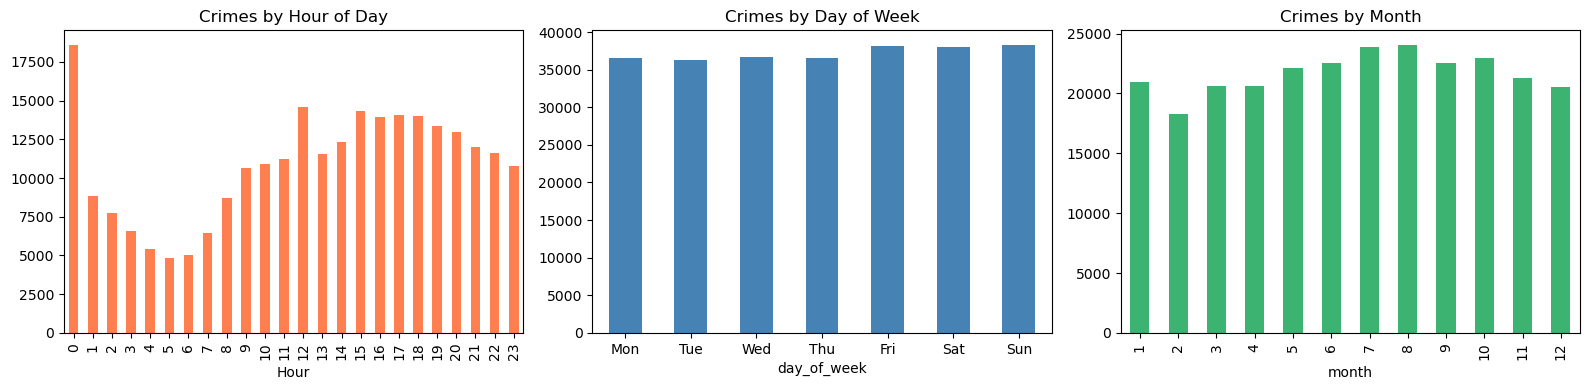

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# By hour
df['hour'].value_counts().sort_index().plot(
    ax=axes[0], kind='bar', color='coral')
axes[0].set_title('Crimes by Hour of Day')
axes[0].set_xlabel('Hour')

# By day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['day_of_week'].value_counts().sort_index().plot(
    ax=axes[1], kind='bar', color='steelblue')
axes[1].set_xticklabels(day_names, rotation=0)
axes[1].set_title('Crimes by Day of Week')

# By month
df['month'].value_counts().sort_index().plot(
    ax=axes[2], kind='bar', color='mediumseagreen')
axes[2].set_title('Crimes by Month')

plt.tight_layout()
plt.show()

In [9]:
# Define violent crime types
violent_types = [
    'BATTERY', 'ASSAULT', 'ROBBERY',
    'HOMICIDE', 'CRIM SEXUAL ASSAULT', 'KIDNAPPING'
]

df['is_violent'] = df['Primary Type'].isin(violent_types).astype(int)

print("Violent crimes:    ", df['is_violent'].sum())
print("Non-violent crimes:", (df['is_violent'] == 0).sum())
print(f"Violent crime rate: {df['is_violent'].mean() * 100:.1f}%")

Violent crimes:     78305
Non-violent crimes: 182139
Violent crime rate: 30.1%


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode District
df['district_encoded'] = le.fit_transform(
    df['District'].fillna('0').astype(str)
)

# Encode Location Description
df['location_encoded'] = le.fit_transform(
    df['Location Description'].fillna('UNKNOWN').astype(str)
)

print("Encoding done.")
print(df[['District', 'district_encoded']].drop_duplicates().head(8))

Encoding done.
    District  district_encoded
0         18                 8
1          9                22
2          6                19
4         25                14
5          1                 0
6         17                 7
7         12                 3
11         7                20


In [11]:
FEATURES = [
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_night',
    'district_encoded',
    'location_encoded',
]

TARGET = 'is_violent'

# Drop any rows with NaN in feature columns
df_model = df[FEATURES + [TARGET, 'Date']].dropna()

print("Final dataset shape:", df_model.shape)
print("\nFeature preview:")
print(df_model[FEATURES].head())
print("\nTarget distribution:")
print(df_model[TARGET].value_counts())

Final dataset shape: (260444, 9)

Feature preview:
   hour  day_of_week  month  is_weekend  is_night  district_encoded  \
0    23            6     12           1         1                 8   
1    23            6     12           1         1                22   
2    23            6     12           1         1                19   
3    23            6     12           1         1                22   
4    23            6     12           1         1                14   

   location_encoded  
0               117  
1               117  
2                17  
3               100  
4               117  

Target distribution:
is_violent
0    182139
1     78305
Name: count, dtype: int64


In [12]:
# Sort by time — never do random split on time-series data
df_model = df_model.sort_values('Date').reset_index(drop=True)

# Use last 15% of data as test set
split_date = df_model['Date'].quantile(0.85)
print("Splitting at date:", split_date)

train = df_model[df_model['Date'] <= split_date]
test  = df_model[df_model['Date'] >  split_date]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"\nTrain size: {len(train):,}")
print(f"Test size:  {len(test):,}")
print(f"Train violent rate: {y_train.mean():.3f}")
print(f"Test violent rate:  {y_test.mean():.3f}")

Splitting at date: 2023-11-04 15:19:06

Train size: 221,377
Test size:  39,067
Train violent rate: 0.301
Test violent rate:  0.300


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import time

print("Training Random Forest... (takes 1-2 mins)")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print(f"Done in {time.time() - start:.1f}s")

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['Non-violent', 'Violent']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Training Random Forest... (takes 1-2 mins)
Done in 3.3s

=== Random Forest Results ===
              precision    recall  f1-score   support

 Non-violent       0.79      0.68      0.73     27335
     Violent       0.44      0.59      0.51     11732

    accuracy                           0.65     39067
   macro avg       0.62      0.64      0.62     39067
weighted avg       0.69      0.65      0.67     39067

ROC-AUC: 0.6836


In [21]:
!pip install xgboost

In [22]:
from xgboost import XGBClassifier
import time

print("Training XGBoost... (takes 1-2 mins)")
start = time.time()

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

print(f"Done in {time.time() - start:.1f}s")

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Non-violent', 'Violent']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Training XGBoost... (takes 1-2 mins)
Done in 3.2s

=== XGBoost Results ===
              precision    recall  f1-score   support

 Non-violent       0.81      0.70      0.75     27335
     Violent       0.47      0.61      0.53     11732

    accuracy                           0.68     39067
   macro avg       0.64      0.66      0.64     39067
weighted avg       0.71      0.68      0.69     39067

ROC-AUC: 0.7112


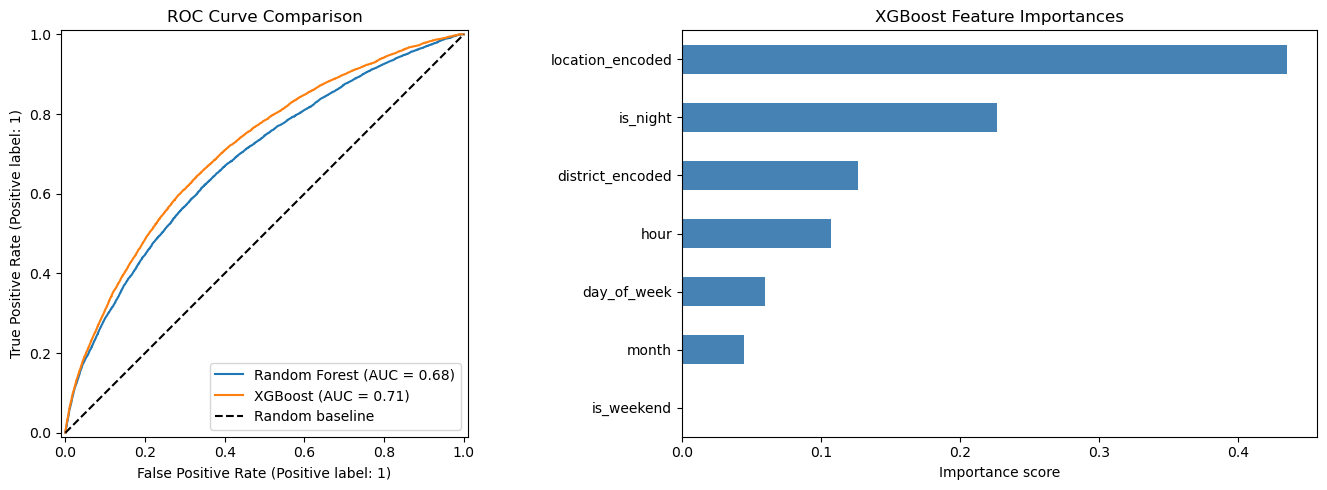

In [23]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,  name='Random Forest', ax=axes[0])
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb, name='XGBoost',       ax=axes[0])
axes[0].plot([0,1],[0,1],'k--', label='Random baseline')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

# XGBoost feature importances
feat_imp = pd.Series(
    xgb.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('XGBoost Feature Importances')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

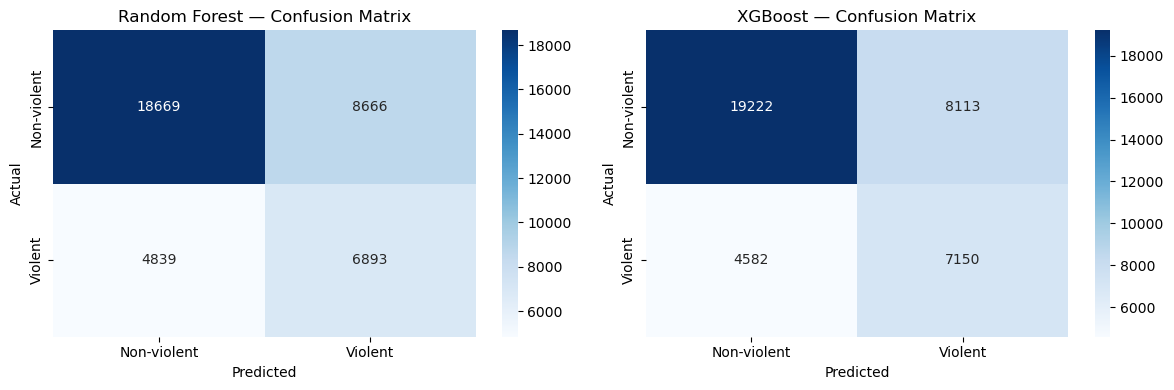

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [
    ('Random Forest', y_pred_rf),
    ('XGBoost',       y_pred_xgb)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-violent','Violent'],
                yticklabels=['Non-violent','Violent'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [26]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# Save XGBoost model
with open('models/crime_model_v1.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save feature list — must match exactly when predicting later
with open('models/crime_features_v1.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("Model saved to models/crime_model_v1.pkl")

# Sanity check — reload and predict one sample
loaded_model = pickle.load(open('models/crime_model_v1.pkl', 'rb'))

test_input = pd.DataFrame([{
    'hour':              23,
    'day_of_week':       5,
    'month':             7,
    'is_weekend':        1,
    'is_night':          1,
    'district_encoded':  3,
    'location_encoded':  10
}])

prob = loaded_model.predict_proba(test_input)[0][1]
print(f"Test prediction — violent crime probability: {prob:.2%}")

Model saved to models/crime_model_v1.pkl
Test prediction — violent crime probability: 35.21%


In [27]:
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [28]:
import folium
from folium.plugins import HeatMap

# Sample 5000 points so map loads fast
sample = df.dropna(subset=['Latitude','Longitude']).sample(5000, random_state=42)

# Create map centered on Chicago
m = folium.Map(
    location=[41.8781, -87.6298],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Add heatmap layer
heat_data = sample[['Latitude','Longitude']].values.tolist()
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.4).add_to(m)

# Save as HTML file
m.save('crime_heatmap.html')
print("Map saved! Open crime_heatmap.html in your browser to see it.")

# Also display inline in Jupyter
m

Map saved! Open crime_heatmap.html in your browser to see it.


In [29]:
!pip install folium xgboost scikit-learn pandas numpy matplotlib seaborn h3

   ---------------------------------------- 0.0/784.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/784.3 kB ? eta -:--:--
   ------------- -------------------------- 262.1/784.3 kB ? eta -:--:--
   ------------------------- ------------ 524.3/784.3 kB 868.6 kB/s eta 0:00:01
   ------------------------- ------------ 524.3/784.3 kB 868.6 kB/s eta 0:00:01
   ------------------------- ------------ 524.3/784.3 kB 868.6 kB/s eta 0:00:01
   ---------------------------------------- 784.3/784.3 kB 577.6 kB/s  0:00:01


In [30]:
!pip install h3

In [31]:
import h3
import pandas as pd

# Assign H3 cell ID to every row at resolution 8
# Resolution 8 = hexagons ~460 metres wide — good neighbourhood level
df['h3_cell'] = df.apply(
    lambda row: h3.latlng_to_cell(row['Latitude'], row['Longitude'], 8),
    axis=1
)

print("H3 cells assigned!")
print(f"Total unique cells: {df['h3_cell'].nunique()}")
print("\nSample:")
print(df[['Latitude','Longitude','h3_cell']].head(5))

H3 cells assigned!
Total unique cells: 851

Sample:
    Latitude  Longitude          h3_cell
0  41.900698 -87.637330  882664c1e5fffff
1  41.801584 -87.633177  882664cc69fffff
2  41.754967 -87.602411  882664cce9fffff
3  41.800201 -87.691535  882664cd43fffff
4  41.906519 -87.758360  882664c847fffff


In [32]:
# Count total crimes per H3 cell
cell_crime_counts = df.groupby('h3_cell').size().reset_index()
cell_crime_counts.columns = ['h3_cell', 'total_crimes_in_cell']

# Count violent crimes per cell
cell_violent_counts = df[df['is_violent']==1].groupby('h3_cell').size().reset_index()
cell_violent_counts.columns = ['h3_cell', 'violent_crimes_in_cell']

# Merge both together
cell_features = cell_crime_counts.merge(cell_violent_counts, on='h3_cell', how='left')
cell_features['violent_crimes_in_cell'] = cell_features['violent_crimes_in_cell'].fillna(0)

# Violent crime rate per cell
cell_features['cell_violent_rate'] = (
    cell_features['violent_crimes_in_cell'] / cell_features['total_crimes_in_cell']
)

print("Cell-level features computed!")
print(f"Total cells: {len(cell_features)}")
print("\nTop 10 most dangerous cells:")
print(cell_features.sort_values('total_crimes_in_cell', ascending=False).head(10))

Cell-level features computed!
Total cells: 851

Top 10 most dangerous cells:
             h3_cell  total_crimes_in_cell  violent_crimes_in_cell  \
211  882664c1a9fffff                  3807                   809.0   
221  882664c1e1fffff                  3256                   694.0   
224  882664c1e7fffff                  2208                   556.0   
222  882664c1e3fffff                  1749                   367.0   
388  882664cad3fffff                  1351                   259.0   
227  882664c1edfffff                  1338                   322.0   
658  882664ceb5fffff                  1291                   484.0   
290  882664c8cbfffff                  1263                   513.0   
537  882664cce1fffff                  1226                   422.0   
202  882664c16bfffff                  1210                   285.0   

     cell_violent_rate  
211           0.212503  
221           0.213145  
224           0.251812  
222           0.209834  
388           0.191710  
22

In [33]:
# For each cell, get the 6 surrounding neighbour cells
# and compute their average crime count — this is called spatial lag

def get_neighbour_avg(cell_id, cell_lookup):
    neighbours = h3.grid_disk(cell_id, 1)  # gets cell + 6 neighbours
    neighbour_counts = [
        cell_lookup.get(n, 0) for n in neighbours if n != cell_id
    ]
    return sum(neighbour_counts) / len(neighbour_counts) if neighbour_counts else 0

# Build a lookup dict for fast access
cell_lookup = dict(zip(
    cell_features['h3_cell'],
    cell_features['total_crimes_in_cell']
))

print("Computing spatial lag (neighbour averages)...")
cell_features['neighbour_avg_crimes'] = cell_features['h3_cell'].apply(
    lambda c: get_neighbour_avg(c, cell_lookup)
)

print("Done!")
print(cell_features[['h3_cell','total_crimes_in_cell','neighbour_avg_crimes']].head(8))

Computing spatial lag (neighbour averages)...
Done!
           h3_cell  total_crimes_in_cell  neighbour_avg_crimes
0  8826641903fffff                    19             23.166667
1  8826641907fffff                     2             21.000000
2  8826641909fffff                     3             33.000000
3  882664190bfffff                    15             18.166667
4  882664190dfffff                     4              0.666667
5  8826641913fffff                    80             19.166667
6  8826641915fffff                    14             73.000000
7  8826641917fffff                   101             72.333333


In [34]:
# Join cell-level features onto every individual incident
df = df.merge(cell_features[['h3_cell',
                              'total_crimes_in_cell',
                              'violent_crimes_in_cell',
                              'cell_violent_rate',
                              'neighbour_avg_crimes']],
              on='h3_cell', how='left')

# Fill any cells that didn't get matched
df[['total_crimes_in_cell',
    'violent_crimes_in_cell',
    'cell_violent_rate',
    'neighbour_avg_crimes']] = df[[
    'total_crimes_in_cell',
    'violent_crimes_in_cell',
    'cell_violent_rate',
    'neighbour_avg_crimes']].fillna(0)

print("Spatial features merged!")
print(f"Dataset shape: {df.shape}")
print(df[['h3_cell','total_crimes_in_cell','cell_violent_rate','neighbour_avg_crimes']].head(5))

Spatial features merged!
Dataset shape: (260444, 36)
           h3_cell  total_crimes_in_cell  cell_violent_rate  \
0  882664c1e5fffff                   920           0.222826   
1  882664cc69fffff                   139           0.258993   
2  882664cce9fffff                  1067           0.373946   
3  882664cd43fffff                   298           0.449664   
4  882664c847fffff                   680           0.342647   

   neighbour_avg_crimes  
0           1421.000000  
1            366.333333  
2            651.500000  
3            291.166667  
4            437.333333  


In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import time

# Updated feature list — now includes spatial features
FEATURES_V2 = [
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_night',
    'district_encoded',
    'location_encoded',
    'total_crimes_in_cell',       # NEW — how busy this hex cell is
    'violent_crimes_in_cell',     # NEW — violent history of this cell
    'cell_violent_rate',          # NEW — what % of crimes here are violent
    'neighbour_avg_crimes',       # NEW — how dangerous surrounding cells are
]

TARGET = 'is_violent'

df_model_v2 = df[FEATURES_V2 + [TARGET, 'Date']].dropna()
df_model_v2 = df_model_v2.sort_values('Date').reset_index(drop=True)

# Same temporal split as before
split_date = df_model_v2['Date'].quantile(0.85)

train_v2 = df_model_v2[df_model_v2['Date'] <= split_date]
test_v2  = df_model_v2[df_model_v2['Date'] >  split_date]

X_train_v2 = train_v2[FEATURES_V2]
y_train_v2 = train_v2[TARGET]
X_test_v2  = test_v2[FEATURES_V2]
y_test_v2  = test_v2[TARGET]

print(f"Train size: {len(train_v2):,}")
print(f"Test size:  {len(test_v2):,}")

scale_pos = (y_train_v2 == 0).sum() / (y_train_v2 == 1).sum()

print("\nTraining XGBoost V2 with spatial features...")
start = time.time()

xgb_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_v2.fit(X_train_v2, y_train_v2,
           eval_set=[(X_test_v2, y_test_v2)],
           verbose=False)

print(f"Done in {time.time() - start:.1f}s")

y_pred_v2 = xgb_v2.predict(X_test_v2)
y_prob_v2 = xgb_v2.predict_proba(X_test_v2)[:, 1]

print("\n=== XGBoost V2 Results (with spatial features) ===")
print(classification_report(y_test_v2, y_pred_v2,
      target_names=['Non-violent','Violent']))
print(f"ROC-AUC: {roc_auc_score(y_test_v2, y_prob_v2):.4f}")

Train size: 221,377
Test size:  39,067

Training XGBoost V2 with spatial features...
Done in 2.6s

=== XGBoost V2 Results (with spatial features) ===
              precision    recall  f1-score   support

 Non-violent       0.81      0.70      0.75     27335
     Violent       0.47      0.62      0.53     11732

    accuracy                           0.68     39067
   macro avg       0.64      0.66      0.64     39067
weighted avg       0.71      0.68      0.69     39067

ROC-AUC: 0.7174


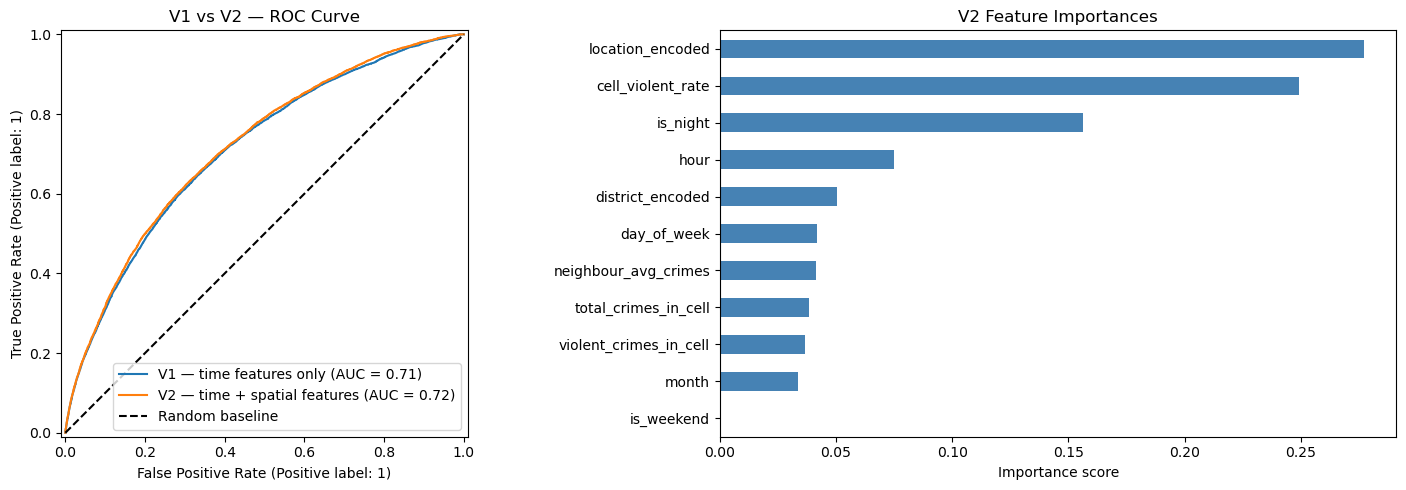


V1 ROC-AUC (time only):         0.7112
V2 ROC-AUC (time + spatial):    0.7174
Improvement:                    +0.0061


In [36]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC comparison
RocCurveDisplay.from_predictions(
    y_test,    y_prob_xgb, name='V1 — time features only', ax=axes[0])
RocCurveDisplay.from_predictions(
    y_test_v2, y_prob_v2,  name='V2 — time + spatial features', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--', label='Random baseline')
axes[0].set_title('V1 vs V2 — ROC Curve')
axes[0].legend()

# Feature importances V2
import pandas as pd
feat_imp = pd.Series(
    xgb_v2.feature_importances_, index=FEATURES_V2
).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('V2 Feature Importances')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

# Print score comparison
auc_v1 = roc_auc_score(y_test, y_prob_xgb)
auc_v2 = roc_auc_score(y_test_v2, y_prob_v2)
print(f"\nV1 ROC-AUC (time only):         {auc_v1:.4f}")
print(f"V2 ROC-AUC (time + spatial):    {auc_v2:.4f}")
print(f"Improvement:                    +{(auc_v2 - auc_v1):.4f}")

In [37]:
import folium
import h3

# Get risk score per cell — use the cell_violent_rate as the risk score
cell_risk = cell_features[['h3_cell','cell_violent_rate','total_crimes_in_cell']].copy()

# Normalize to 0-1
cell_risk['risk_score'] = (
    cell_risk['cell_violent_rate'] / cell_risk['cell_violent_rate'].max()
)

def risk_color(score):
    if score > 0.8: return '#E24B4A'   # red
    if score > 0.6: return '#EF9F27'   # orange
    if score > 0.4: return '#FAC775'   # yellow
    if score > 0.2: return '#97C459'   # light green
    return '#1D9E75'                    # green

m2 = folium.Map(location=[41.8781, -87.6298], zoom_start=11,
                tiles='CartoDB positron')

# Draw each H3 hexagon colored by risk score
for _, row in cell_risk.iterrows():
    try:
        boundary = h3.cell_to_boundary(row['h3_cell'])
        coords = [[lat, lon] for lat, lon in boundary]
        folium.Polygon(
            locations=coords,
            fill=True,
            fill_color=risk_color(row['risk_score']),
            fill_opacity=0.6,
            color='white',
            weight=0.5,
            tooltip=f"Risk: {row['risk_score']:.2f} | Crimes: {int(row['total_crimes_in_cell'])}"
        ).add_to(m2)
    except Exception:
        continue

m2.save('risk_map.html')
print("Risk map saved as risk_map.html — open in browser to see hex grid!")
m2

Risk map saved as risk_map.html — open in browser to see hex grid!


In [38]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# Save V2 model
with open('models/crime_model_v2.pkl', 'wb') as f:
    pickle.dump(xgb_v2, f)

# Save V2 feature list
with open('models/crime_features_v2.pkl', 'wb') as f:
    pickle.dump(FEATURES_V2, f)

# Save cell features table — needed by the API to look up spatial features
cell_features.to_csv('models/cell_features.csv', index=False)

print("V2 model saved!")
print("Files saved:")
print("  models/crime_model_v2.pkl")
print("  models/crime_features_v2.pkl")
print("  models/cell_features.csv")

V2 model saved!
Files saved:
  models/crime_model_v2.pkl
  models/crime_features_v2.pkl
  models/cell_features.csv


In [39]:
import pandas as pd
import numpy as np

# Sort by date first
df = df.sort_values('Date').reset_index(drop=True)

print("Computing rolling crime counts per H3 cell...")
print("This takes 2-3 minutes — please wait...")

# Set date as index temporarily for rolling
df['date_only'] = df['Date'].dt.date

# Count crimes per cell per day
daily_cell = df.groupby(['h3_cell', 'date_only']).agg(
    daily_crimes   = ('is_violent', 'count'),
    daily_violent  = ('is_violent', 'sum')
).reset_index()

daily_cell['date_only'] = pd.to_datetime(daily_cell['date_only'])
daily_cell = daily_cell.sort_values(['h3_cell','date_only'])

# Rolling 7-day and 30-day crime count per cell
# shift(1) means we only use PAST data — no leakage
daily_cell['crimes_last_7d'] = daily_cell.groupby('h3_cell')['daily_crimes'] \
    .transform(lambda x: x.shift(1).rolling(7,  min_periods=1).sum())

daily_cell['crimes_last_30d'] = daily_cell.groupby('h3_cell')['daily_crimes'] \
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).sum())

daily_cell['violent_last_7d'] = daily_cell.groupby('h3_cell')['daily_violent'] \
    .transform(lambda x: x.shift(1).rolling(7,  min_periods=1).sum())

print("Rolling features computed!")
print(daily_cell.head(10))

Computing rolling crime counts per H3 cell...
This takes 2-3 minutes — please wait...
Rolling features computed!
           h3_cell  date_only  daily_crimes  daily_violent  crimes_last_7d  \
0  8826641903fffff 2023-02-02             1              0             NaN   
1  8826641903fffff 2023-02-10             1              1             1.0   
2  8826641903fffff 2023-02-15             1              0             2.0   
3  8826641903fffff 2023-03-09             1              1             3.0   
4  8826641903fffff 2023-03-24             1              0             4.0   
5  8826641903fffff 2023-04-28             1              0             5.0   
6  8826641903fffff 2023-05-21             1              0             6.0   
7  8826641903fffff 2023-06-02             1              0             7.0   
8  8826641903fffff 2023-07-17             1              1             7.0   
9  8826641903fffff 2023-07-28             1              0             7.0   

   crimes_last_30d  violent_

In [43]:
# Merge rolling features onto main df by cell + date
df['date_only'] = pd.to_datetime(df['date_only'])

df = df.merge(
    daily_cell[['h3_cell','date_only',
                'crimes_last_7d',
                'crimes_last_30d',
                'violent_last_7d']],
    on=['h3_cell','date_only'],
    how='left'
)

# Fill NaN with 0 for cells with no prior history
df[['crimes_last_7d','crimes_last_30d','violent_last_7d']] = \
    df[['crimes_last_7d','crimes_last_30d','violent_last_7d']].fillna(0)

print("Merged successfully!")
print(f"Dataset shape: {df.shape}")
print(df[['h3_cell','date_only','crimes_last_7d','crimes_last_30d','violent_last_7d']].head(8))

Merged successfully!
Dataset shape: (260444, 49)
           h3_cell  date_only  crimes_last_7d  crimes_last_30d  \
0  882664cf37fffff 2023-01-01             0.0              0.0   
1  882664562dfffff 2023-01-01             0.0              0.0   
2  882664d89dfffff 2023-01-01             0.0              0.0   
3  88266452ddfffff 2023-01-01             0.0              0.0   
4  882664ca83fffff 2023-01-01             0.0              0.0   
5  882664cd13fffff 2023-01-01             0.0              0.0   
6  882664cdc5fffff 2023-01-01             0.0              0.0   
7  882664d8bdfffff 2023-01-01             0.0              0.0   

   violent_last_7d  
0              0.0  
1              0.0  
2              0.0  
3              0.0  
4              0.0  
5              0.0  
6              0.0  
7              0.0  


In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import time

FEATURES_V3 = [
    # Time features
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_night',
    # Encoded location
    'district_encoded',
    'location_encoded',
    # Static spatial features
    'total_crimes_in_cell',
    'cell_violent_rate',
    'neighbour_avg_crimes',
    'cell_danger_rank',
    # Rolling time-windowed features (the new powerful ones)
    'crimes_last_7d',
    'crimes_last_30d',
    'violent_last_7d',
    # Interaction features
    'hour_risk',
    'dow_risk',
]

TARGET = 'is_violent'

df_model_v3 = df[FEATURES_V3 + [TARGET, 'Date']].dropna()
df_model_v3 = df_model_v3.sort_values('Date').reset_index(drop=True)

split_date = df_model_v3['Date'].quantile(0.85)

train_v3 = df_model_v3[df_model_v3['Date'] <= split_date]
test_v3  = df_model_v3[df_model_v3['Date'] >  split_date]

X_train_v3 = train_v3[FEATURES_V3]
y_train_v3 = train_v3[TARGET]
X_test_v3  = test_v3[FEATURES_V3]
y_test_v3  = test_v3[TARGET]

print(f"Train: {len(train_v3):,} rows")
print(f"Test:  {len(test_v3):,} rows")

scale_pos = (y_train_v3 == 0).sum() / (y_train_v3 == 1).sum()

print("\nTraining XGBoost V3...")
start = time.time()

xgb_v3 = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_v3.fit(X_train_v3, y_train_v3,
           eval_set=[(X_test_v3, y_test_v3)],
           verbose=False)

print(f"Done in {time.time() - start:.1f}s")

y_pred_v3 = xgb_v3.predict(X_test_v3)
y_prob_v3 = xgb_v3.predict_proba(X_test_v3)[:, 1]

auc_v1 = roc_auc_score(y_test,    y_prob_xgb)
auc_v2 = roc_auc_score(y_test_v2, y_prob_v2)
auc_v3 = roc_auc_score(y_test_v3, y_prob_v3)

print("\n=== All Model Comparison ===")
print(f"V1 — time features only:          {auc_v1:.4f}")
print(f"V2 — time + static spatial:       {auc_v2:.4f}")
print(f"V3 — time + spatial + rolling:    {auc_v3:.4f}")
print(f"\nTotal improvement V1 → V3:        +{(auc_v3 - auc_v1):.4f}")

print("\n=== V3 Classification Report ===")
print(classification_report(y_test_v3, y_pred_v3,
      target_names=['Non-violent','Violent']))

Train: 221,377 rows
Test:  39,067 rows

Training XGBoost V3...
Done in 3.5s

=== All Model Comparison ===
V1 — time features only:          0.7112
V2 — time + static spatial:       0.7174
V3 — time + spatial + rolling:    0.7199

Total improvement V1 → V3:        +0.0086

=== V3 Classification Report ===
              precision    recall  f1-score   support

 Non-violent       0.81      0.71      0.76     27335
     Violent       0.48      0.61      0.54     11732

    accuracy                           0.68     39067
   macro avg       0.64      0.66      0.65     39067
weighted avg       0.71      0.68      0.69     39067



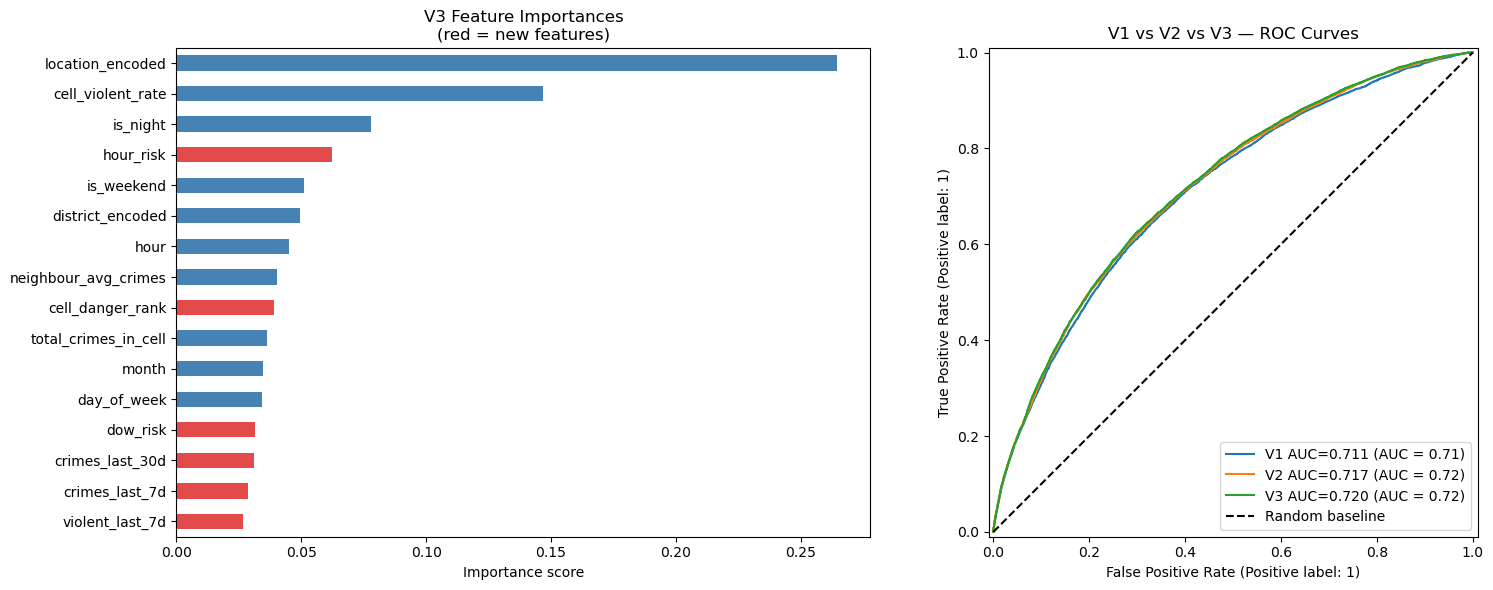

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importances
feat_imp = pd.Series(
    xgb_v3.feature_importances_, index=FEATURES_V3
).sort_values()

colors = ['#E24B4A' if 'last' in f or 'risk' in f or 'rank' in f
          else 'steelblue' for f in feat_imp.index]

feat_imp.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('V3 Feature Importances\n(red = new features)')
axes[0].set_xlabel('Importance score')

# V1 vs V2 vs V3 ROC curves
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(
    y_test,    y_prob_xgb, name=f'V1 AUC={auc_v1:.3f}', ax=axes[1])
RocCurveDisplay.from_predictions(
    y_test_v2, y_prob_v2,  name=f'V2 AUC={auc_v2:.3f}', ax=axes[1])
RocCurveDisplay.from_predictions(
    y_test_v3, y_prob_v3,  name=f'V3 AUC={auc_v3:.3f}', ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', label='Random baseline')
axes[1].set_title('V1 vs V2 vs V3 — ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
import pickle, os

os.makedirs('models', exist_ok=True)

with open('models/crime_model_v3.pkl', 'wb') as f:
    pickle.dump(xgb_v3, f)

with open('models/crime_features_v3.pkl', 'wb') as f:
    pickle.dump(FEATURES_V3, f)

cell_features.to_csv('models/cell_features.csv', index=False)
daily_cell.to_csv('models/daily_cell_features.csv', index=False)

print("V3 model saved — this is your production model.")
print("\nFiles saved:")
print("  models/crime_model_v3.pkl        <- the model")
print("  models/crime_features_v3.pkl     <- feature names")
print("  models/cell_features.csv         <- static cell stats")
print("  models/daily_cell_features.csv   <- rolling daily stats")

V3 model saved — this is your production model.

Files saved:
  models/crime_model_v3.pkl        <- the model
  models/crime_features_v3.pkl     <- feature names
  models/cell_features.csv         <- static cell stats
  models/daily_cell_features.csv   <- rolling daily stats
